Importing Libraries

In [ ]:
import numpy as np
import pandas as pd
import os
from keras.preprocessing import image
import matplotlib.pyplot as plt
from keras.models import Sequential, Model
from keras.layers import Dense, Conv2D, MaxPooling2D,MaxPool2D ,UpSampling2D, Flatten, Input
from keras.optimizers import SGD, Adam, Adadelta, Adagrad
from keras import backend as K
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
import cv2
from math import log10,sqrt

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
path = '/content/gdrive/MyDrive/Covid_CT/COVID'

In [ ]:
train_images=sorted(os.listdir('/content/gdrive/MyDrive/Covid_CT/COVID'))


In [ ]:
print(train_images)

['Covid (1).png', 'Covid (10).png', 'Covid (100).png', 'Covid (1000).png', 'Covid (1001).png', 'Covid (1002).png', 'Covid (1003).png', 'Covid (1004).png', 'Covid (1005).png', 'Covid (1006).png', 'Covid (1007).png', 'Covid (1008).png', 'Covid (1009).png', 'Covid (101).png', 'Covid (1010).png', 'Covid (1011).png', 'Covid (1012).png', 'Covid (1013).png', 'Covid (1014).png', 'Covid (1015).png', 'Covid (1016).png', 'Covid (1017).png', 'Covid (1018).png', 'Covid (1019).png', 'Covid (102).png', 'Covid (1020).png', 'Covid (1021).png', 'Covid (1022).png', 'Covid (1023).png', 'Covid (1024).png', 'Covid (1025).png', 'Covid (1026).png', 'Covid (1027).png', 'Covid (1028).png', 'Covid (1029).png', 'Covid (103).png', 'Covid (1030).png', 'Covid (1031).png', 'Covid (1032).png', 'Covid (1033).png', 'Covid (1034).png', 'Covid (1035).png', 'Covid (1036).png', 'Covid (1037).png', 'Covid (1038).png', 'Covid (1039).png', 'Covid (104).png', 'Covid (1040).png', 'Covid (1041).png', 'Covid (1042).png', 'Covid (1

Analyzing Image Data

In [ ]:
train_image=[]
for im in train_images:
  img=image.load_img('/content/gdrive/MyDrive/Covid_CT/COVID/'+im,target_size=(128,128),color_mode='grayscale')
  img=image.img_to_array(img)
  img=img/255
  train_image.append(img)

train_df=np.array(train_image)

In [ ]:
#Subplotting images
def plot_img(dataset):
  f,ax=plt.subplots(1,5)
  f.set_size_inches(40,20)
  for i in range(5,10):
    ax[i-5].imshow(dataset[i].reshape(128,128), cmap='gray')
  plt.show()

Adding Noise to the data

In [ ]:
#Adding gaussian noise with 0.05 factor
def add_noise(image):
  row,col,ch=image.shape
  mean=0
  sigma=1
  gauss=np.random.normal(mean,sigma,(row,col,ch))
  gauss=gauss.reshape(row,col,ch)
  noisy=image+gauss*0.05
  return noisy


In [ ]:
noised_df=[]
for img in train_df:
  noisy=add_noise(img)
  noised_df.append(noisy)

noised_df=np.array(noised_df)

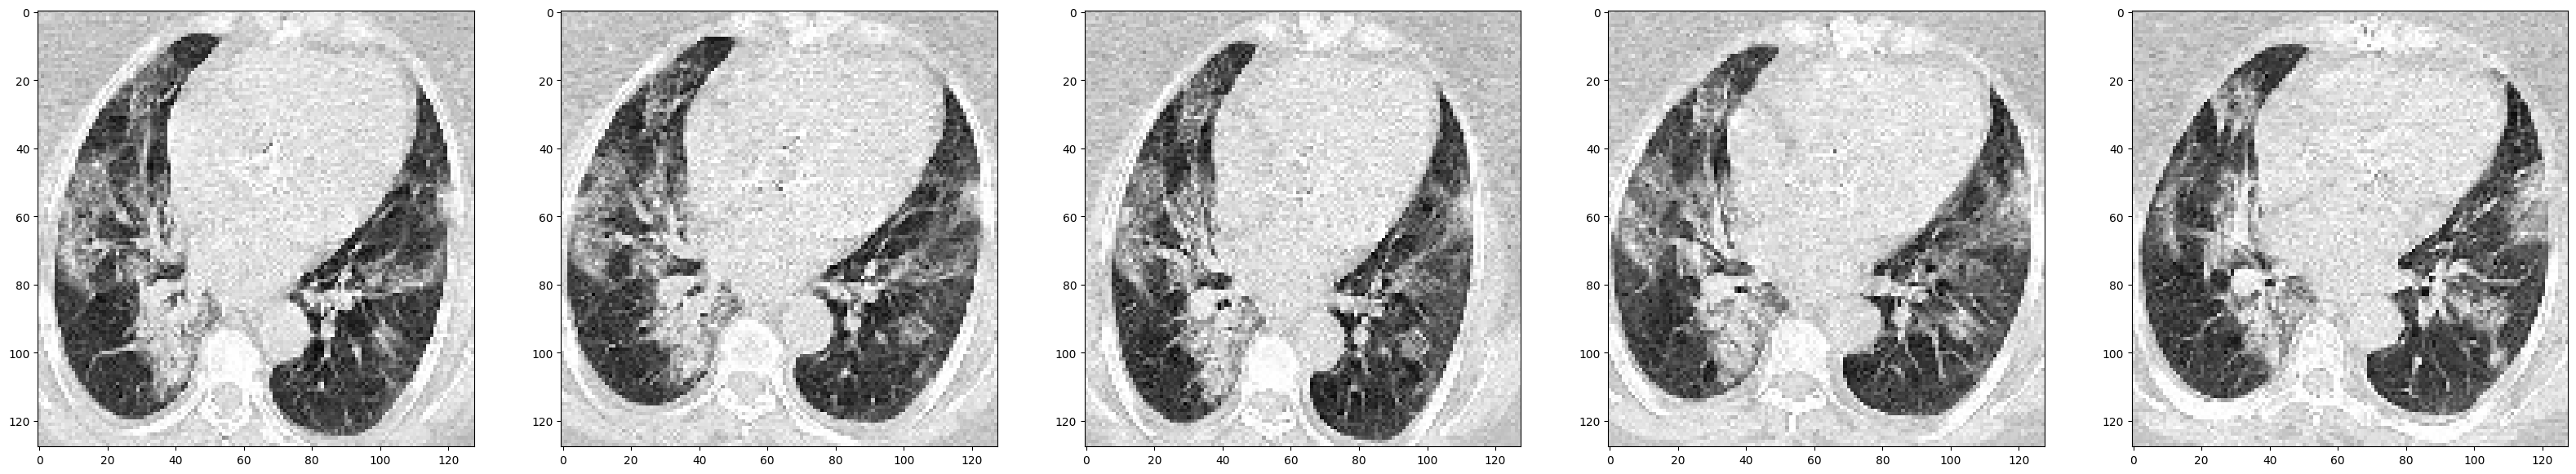

In [ ]:
plot_img(train_df)

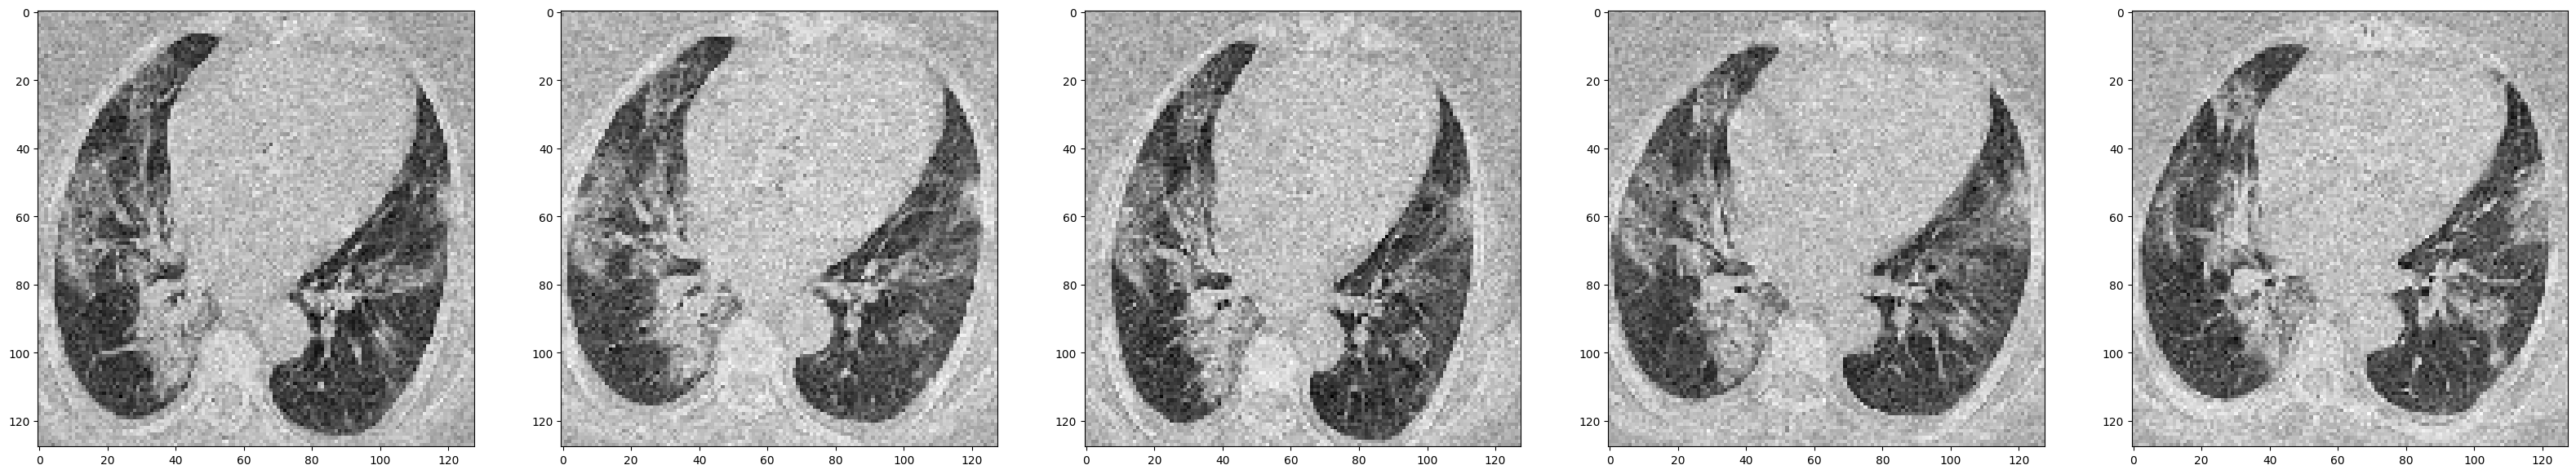

In [ ]:
plot_img(noised_df)

In [ ]:
noised_df.shape

(1252, 128, 128, 1)

In [ ]:
xnoised=noised_df[:800]
xtest=noised_df[800:]

In [ ]:
xclean = train_df[:800]

In [ ]:
cleantest = train_df[800:]

In [ ]:
xtest.shape

(452, 128, 128, 1)

Autoencoder based Denoising Model

In [ ]:
def autoencoder():
  input_img=Input(shape=(128,128,1),name='image_input')
  #enoder
  x = Conv2D(64, (3,3), activation='relu', padding='same', name='Conv1')(input_img)
  x = MaxPooling2D((2,2), padding='same', name='pool1')(x)
  x = Conv2D(64, (3,3), activation='relu', padding='same', name='Conv2')(x)
  x = MaxPooling2D((2,2), padding='same', name='pool2')(x)

  #decoder
  x = Conv2D(64, (3,3), activation='relu', padding='same', name='Conv3')(x)
  x = UpSampling2D((2,2), name='upsample1')(x)
  x = Conv2D(64, (3,3), activation='relu', padding='same', name='Conv4')(x)
  x = UpSampling2D((2,2), name='upsample2')(x)
  x = Conv2D(1, (3,3), activation='sigmoid', padding='same', name='Conv5')(x)

  #model
  autoencoder = Model(inputs=input_img, outputs=x)
  autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

  return autoencoder

In [ ]:
model= autoencoder()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv1 (Conv2D)                  │ (None, 128, 128, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2 (Conv2D)                  │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv3 (Conv2D)                  │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ upsample1 (UpSampling2D)        │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv4 (Conv2D)                  │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ upsample2 (UpSampling2D)        │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv5 (Conv2D)                  │ (None, 128, 128, 1)    │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 112,001 (437.50 KB)

 Trainable params: 112,001 (437.50 KB)

 Non-trainable params: 0 (0.00 B)

Train the model

In [ ]:
with tf.device('/device:GPU:0'):
    early_stopping = EarlyStopping(monitor='val_loss', min_delta=0, patience=10, verbose=1, mode='auto')
    model.fit(xnoised, xclean, epochs=5, batch_size=10, validation_data=(xtest, xtest), callbacks=[early_stopping])

Epoch 1/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 112s 1s/step - loss: 0.5696 - val_loss: 0.4930
Epoch 2/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - loss: 0.4919 - val_loss: 0.4862
Epoch 3/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 152s 1s/step - loss: 0.4880 - val_loss: 0.4829
Epoch 4/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - loss: 0.4815 - val_loss: 0.4831
Epoch 5/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - loss: 0.4828 - val_loss: 0.4830


In [ ]:
xtrain= train_df[800:]

Plot and Analyze Predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 548ms/step


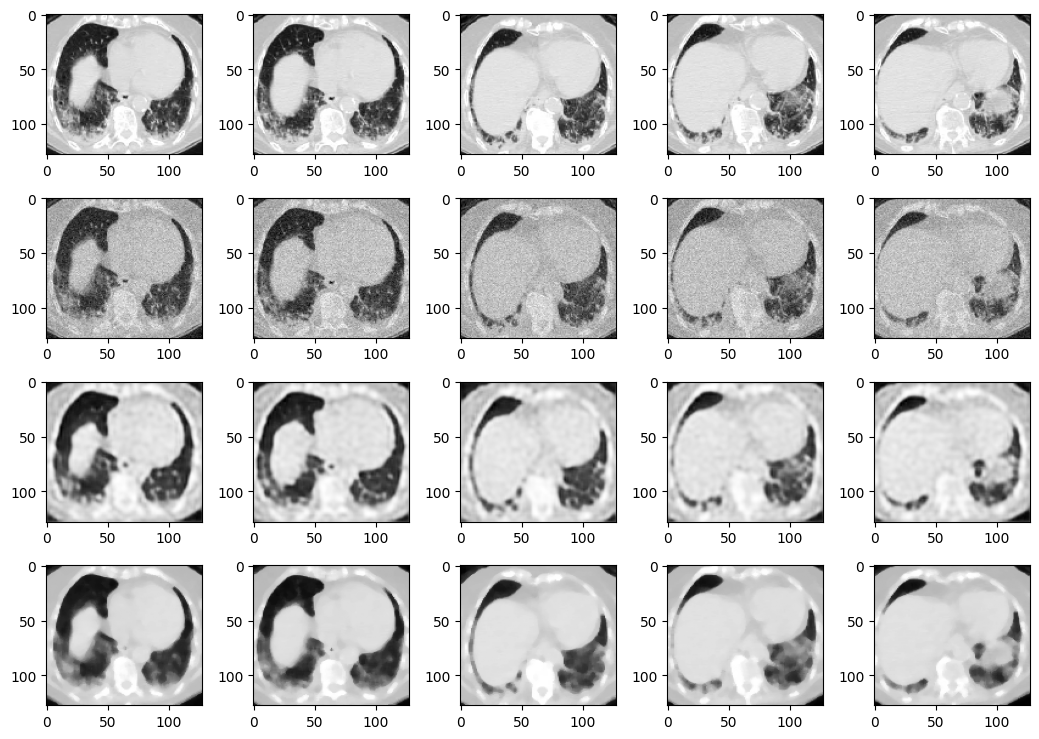

In [ ]:
pred= model.predict(xtest[:5])
def plot_predictions(y_true, y_pred):
    f, ax = plt.subplots(4, 5)
    f.set_size_inches(10.5,7.5)
    for i in range(5):
        ax[0][i].imshow(np.reshape(xtrain[i], (128,128)), aspect='auto', cmap='gray')
        ax[1][i].imshow(np.reshape(y_true[i], (128,128)), aspect='auto', cmap='gray')
        ax[2][i].imshow(np.reshape(y_pred[i], (128,128)), aspect='auto', cmap='gray')
        ax[3][i].imshow(cv2.medianBlur(xtrain[i], (5)), aspect='auto', cmap='gray')
    plt.tight_layout()
plot_predictions(xtest[:5], pred[:5])

Comparison of our Denoising model with pre-existing denoising techniques

Text(0.5, 1.0, 'Bilateral Filter')

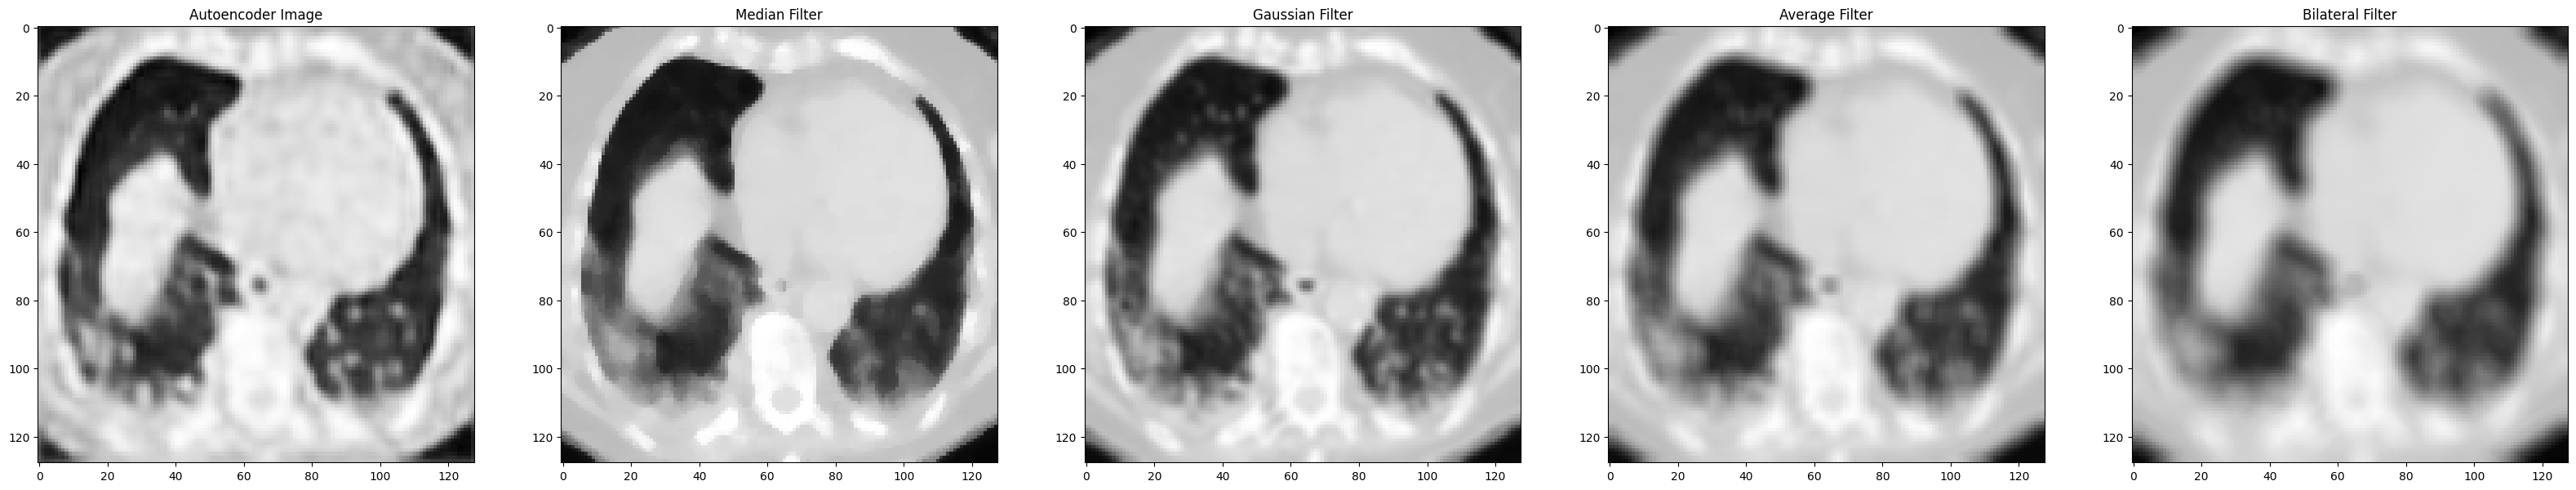

In [ ]:
median_blur = cv2.medianBlur(xtrain[0], (5))
gaussian_blur=cv2.GaussianBlur(xtrain[0],(5,5),0)
average_blur=cv2.blur(xtrain[0],(5,5))
bilateral_filter=cv2.bilateralFilter(xtrain[0],9,75,75)
f,ax=plt.subplots(1,5)
f.set_size_inches(40,20)
ax[0].imshow(pred[0].reshape(128,128), cmap='gray')
ax[0].set_title('Autoencoder Image')
ax[1].imshow(median_blur,cmap='gray')
ax[1].set_title('Median Filter')
ax[2].imshow(gaussian_blur,cmap='gray')
ax[2].set_title('Gaussian Filter')
ax[3].imshow(average_blur,cmap='gray')
ax[3].set_title('Average Filter')
ax[4].imshow(bilateral_filter,cmap='gray')
ax[4].set_title('Bilateral Filter')

Text(0.5, 1.0, 'Average Blur')

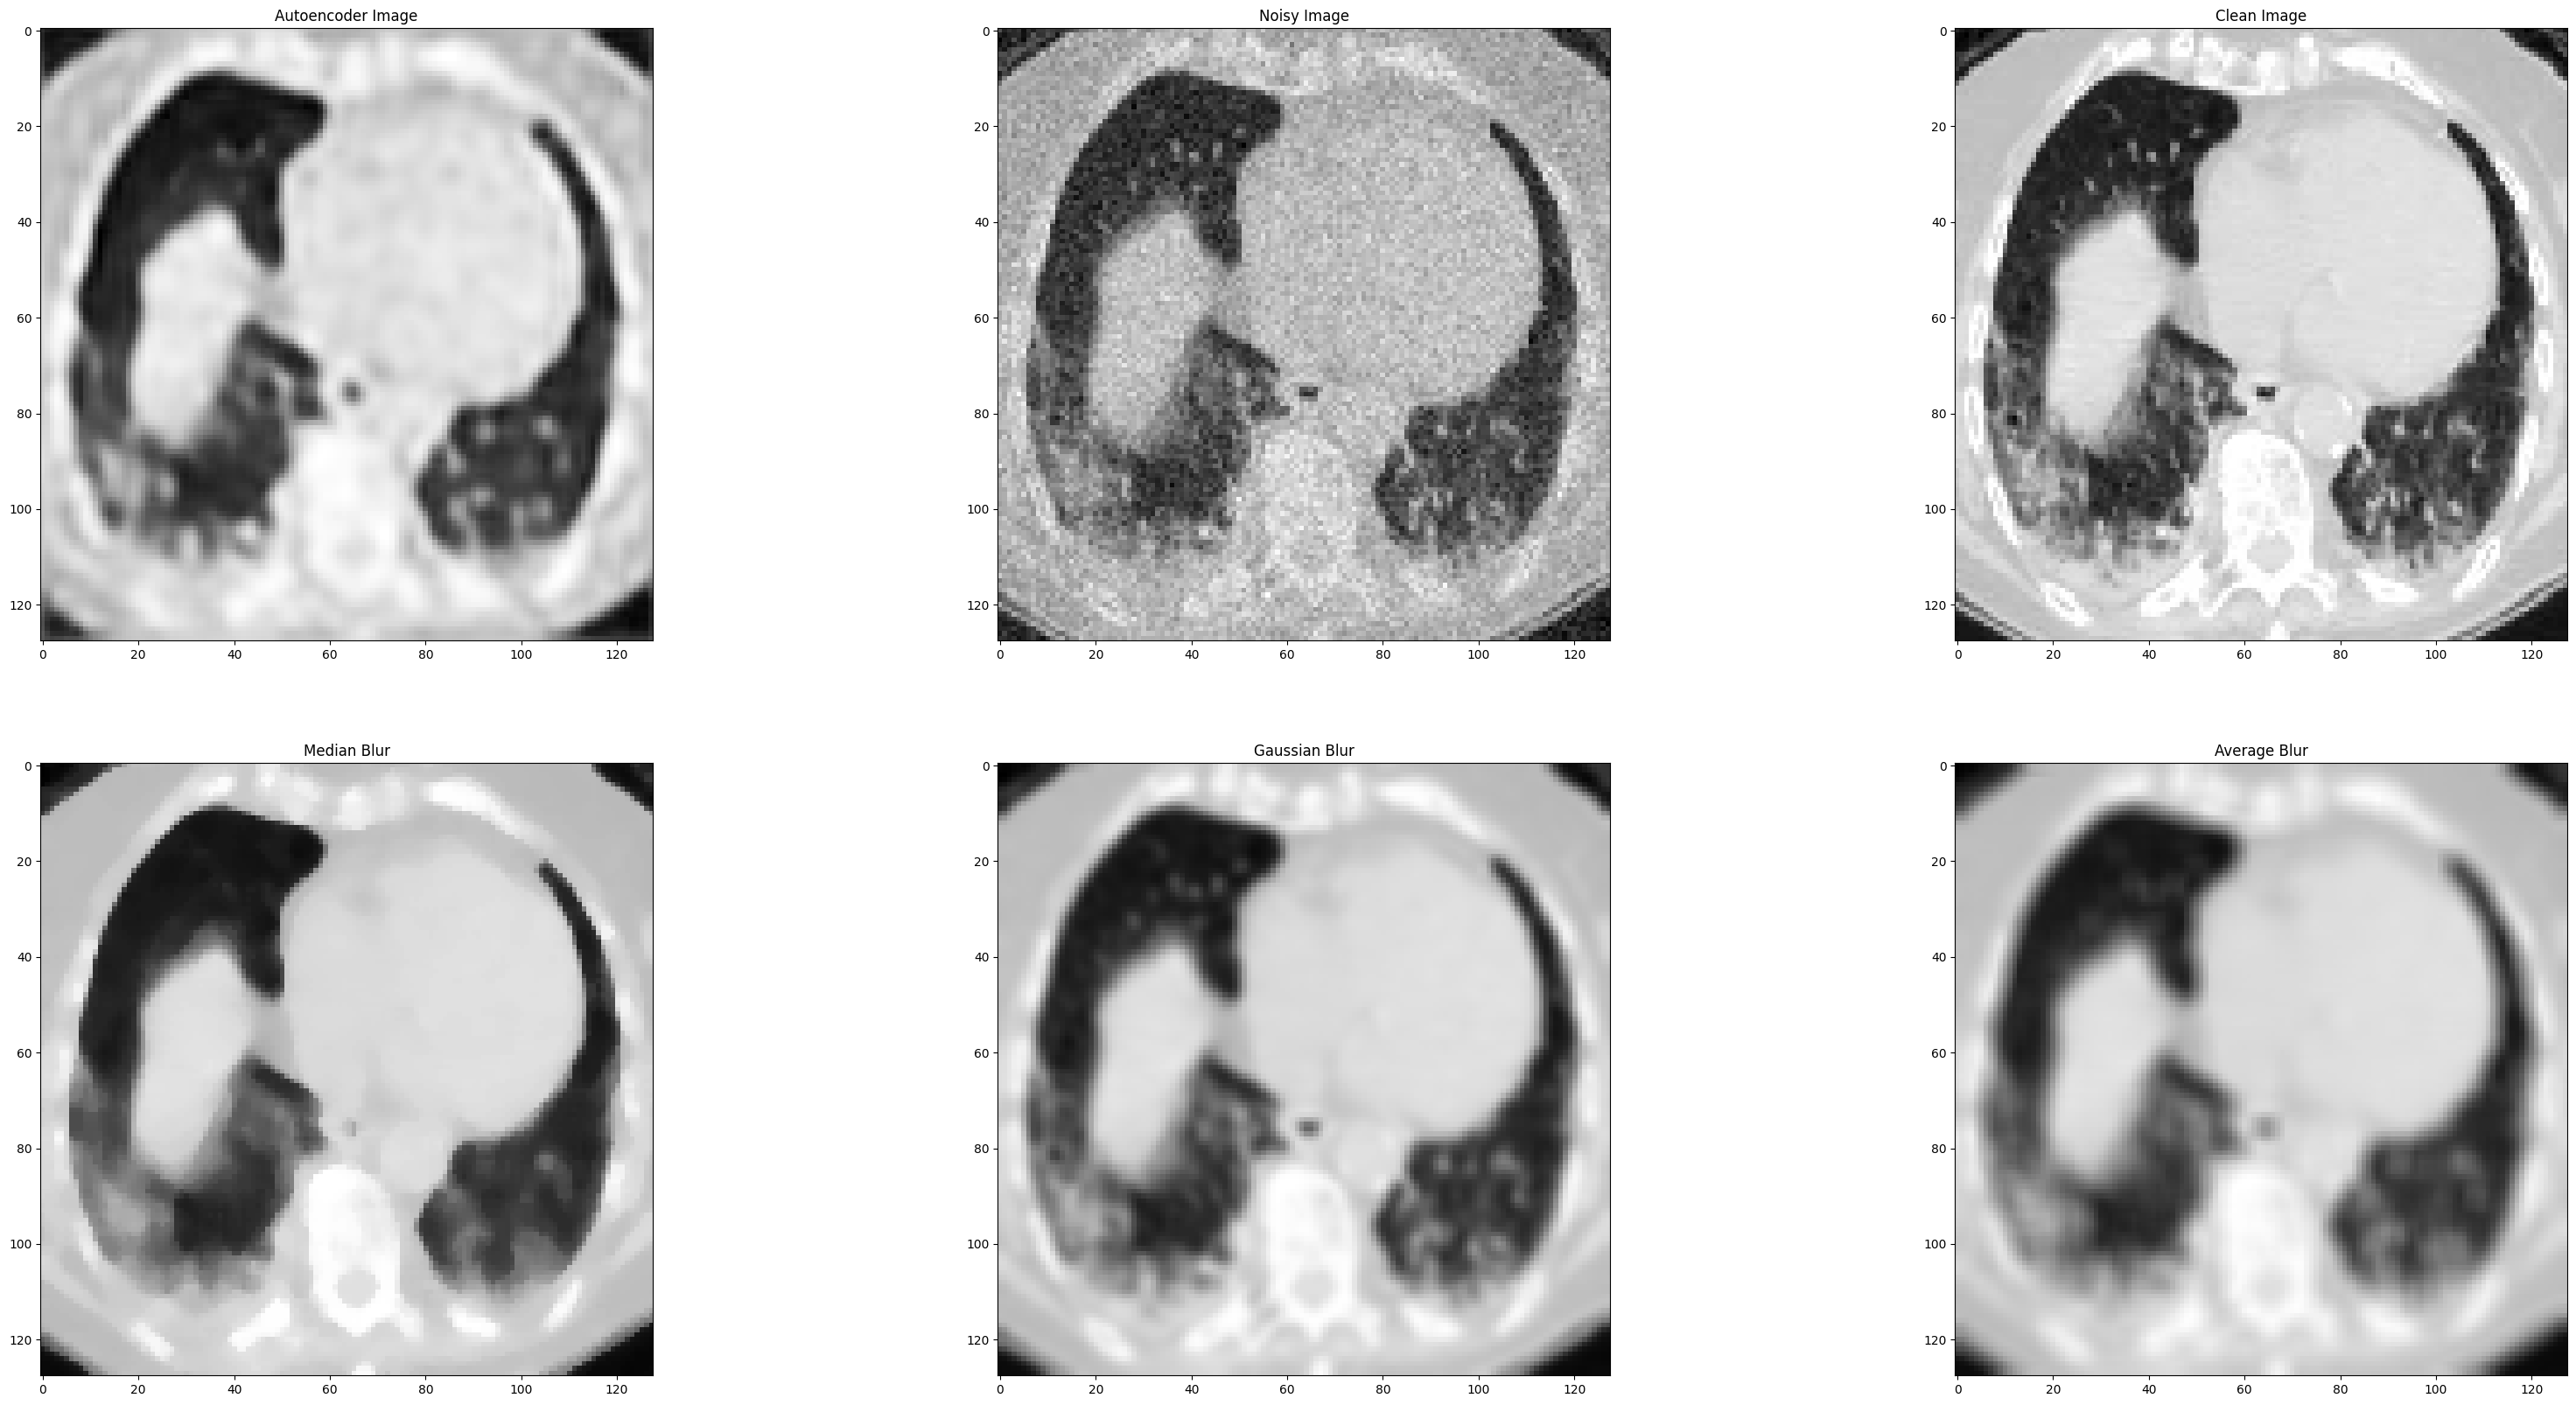

In [ ]:
median_blur = cv2.medianBlur(xtrain[0], (5))
gaussian_blur=cv2.GaussianBlur(xtrain[0],(5,5),0)
average_blur=cv2.blur(xtrain[0],(5,5))
bilateral_filter=cv2.bilateralFilter(xtrain[0],9,75,75)
f,ax=plt.subplots(2,3)
f.set_size_inches(40,20)
ax[0][0].imshow(pred[0].reshape(128,128), cmap='gray')
ax[0][0].set_title('Autoencoder Image')
ax[0][1].imshow(xtest[0].reshape(128, 128), cmap= 'gray')
ax[0][1].set_title('Noisy Image')
ax[0][2].imshow(train_df[800],cmap='gray')
ax[0][2].set_title('Clean Image')
ax[1][0].imshow(median_blur,cmap='gray')
ax[1][0].set_title('Median Blur')
ax[1][1].imshow(gaussian_blur,cmap='gray')
ax[1][1].set_title('Gaussian Blur')
ax[1][2].imshow(average_blur, cmap= 'gray')
ax[1][2].set_title('Average Blur')


Comparing the PSNR values

In [ ]:
  def PSNR(original, denoised):
    mse = np.mean((original - denoised) ** 2)
    if(mse == 0):
        return 100
    max_pixel = 255.0
    psnr = 20 * log10(max_pixel / sqrt(mse))
    return psnr


value1 = PSNR(xtrain[0], median_blur)
value2 = PSNR(xtrain[0], pred[0])
value3 = PSNR(xtrain[0], gaussian_blur)
value4 = PSNR(xtrain[0], average_blur)
value5 = PSNR(xtrain[0], bilateral_filter)

print("PSNR values")
print(f"Autoencoder Image : {value2} dB")
print(f"Median Filter Image : {value1} dB")
print(f"Gaussian Filter Image : {value3} dB")
print(f"Average Filter Image : {value4} dB")
print(f"Bilateral Filter Image : {value5} dB")

PSNR values
Autoencoder Image : 73.99829022325923 dB
Median Filter Image : 58.93464159200277 dB
Gaussian Filter Image : 59.05600663245903 dB
Average Filter Image : 59.176023834003345 dB
Bilateral Filter Image : 59.333227482169626 dB


In [ ]:
autoencoded_img_mtrx = pred[0].reshape(128, 128)


In [ ]:
np.savetxt("autoencoded_img_mtrx.txt", autoencoded_img_mtrx, fmt="%.6f")

In [ ]:
xtest[0].shape

(128, 128, 1)

In [ ]:
noisy_img_mtrx = xtest[0].reshape(128, 128)

In [ ]:
np.savetxt("noisy_img_mtrx.txt", noisy_img_mtrx, fmt="%.6f")

CONCLUSION:
  Our autoencoder-based denoising model achieved superior PSNR compared to traditional denoising techniques that do not learn from data. Unlike fixed filters, autoencoders adaptively learn to adjust convolutional weights based on the significance and detail of image regions. This allows the model to apply stronger smoothing to less critical areas while preserving fine details in more important regions, resulting in more effective and context-aware denoising.